In [67]:
#importation of the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [68]:
#loading the data
df= pd.read_csv("paywave_transactions_2024.csv")
df.head()

,Transaction_ID,Date,Market,Category,Amount_USD,Fee_USD,Payment_Type,Fraud_Flag,Merchant,Customer_Tier
0,TXN-00001,2024-09-01,South Africa,Electronics,126.87,3.04,Card,No,Woolworths,Standard
1,TXN-00002,2024-01-07,Nigeria,Utilities,74.44,1.76,Mobile Money,No,Air Peace,Standard
2,TXN-00003,2024-11-01,South Africa,Groceries,39.12,0.77,Card,No,DSTV SA,Standard
3,TXN-00004,2024-02-28,Nigeria,Electronics,394.57,7.50,QR Code,No,Air Peace,Standard
4,TXN-00005,2024-11-20,South Africa,Food & Dining,8.83,0.21,Card,No,Netcare,Standard


In [69]:

#converting the date column to datetime format
df["Date"] = pd.to_datetime(df["Date"])
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Transaction_ID  1200 non-null   str           
 1   Date            1200 non-null   datetime64[us]
 2   Market          1200 non-null   str           
 3   Category        1200 non-null   str           
 4   Amount_USD      1200 non-null   float64       
 5   Fee_USD         1200 non-null   float64       
 6   Payment_Type    1200 non-null   str           
 7   Fraud_Flag      1200 non-null   str           
 8   Merchant        1200 non-null   str           
 9   Customer_Tier   1200 non-null   str           
dtypes: datetime64[us](1), float64(2), str(7)
memory usage: 93.9 KB


In [70]:
#checking duplicate values
df.duplicated().sum() #no duplicate values
#checking for missing values
df.isnull().sum() #no missing values

Transaction_ID    0
Date              0
Market            0
Category          0
Amount_USD        0
Fee_USD           0
Payment_Type      0
Fraud_Flag        0
Merchant          0
Customer_Tier     0
dtype: int64

In [71]:
#which markeT is marking MOST transaction
df["Market"].value_counts().head()

Market
South Africa    343
Nigeria         341
Kenya           269
Ghana           247
Name: count, dtype: int64

In [72]:
#trend of transactions over months
df["Month"] = pd.Categorical(
    df["Date"].dt.month_name(),
    categories=[
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ],
    ordered=True
)

monthly_transactions = df.groupby("Month").size()

print(monthly_transactions)

Month
January       82
February     105
March         87
April         94
May           84
June          97
July         105
August        94
September     96
October       99
November     122
December     135
dtype: int64


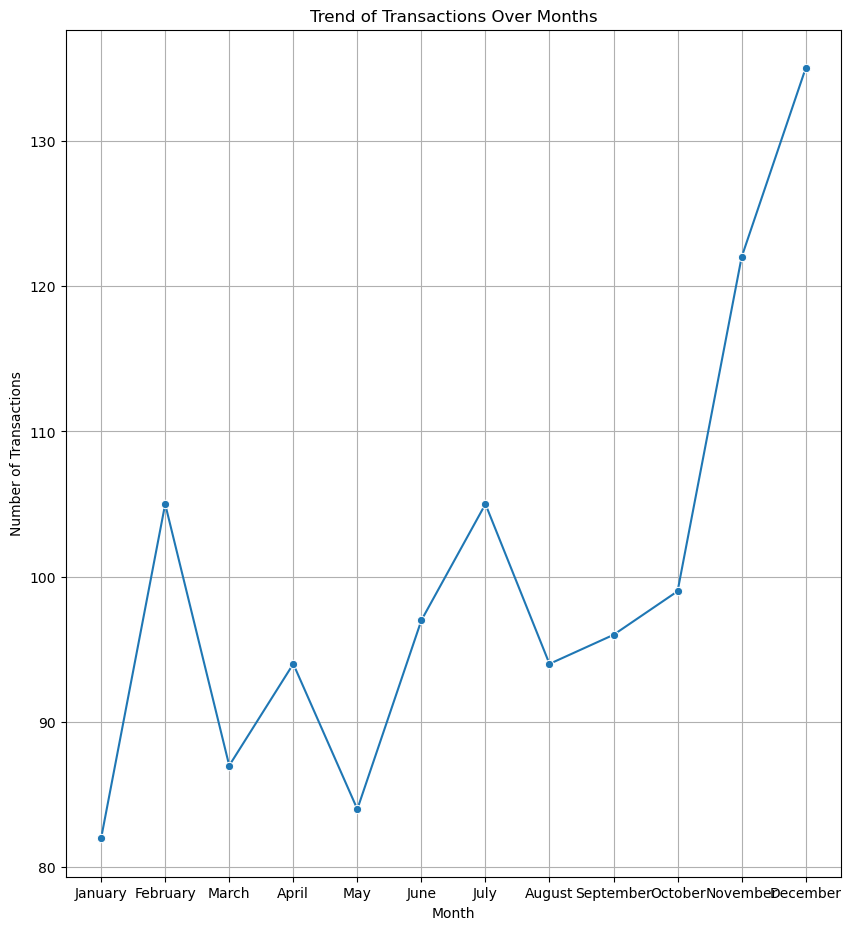

In [73]:
#trend of transactions over months

plt.figure(figsize=(10, 11))
sns.lineplot(x=monthly_transactions.index, y=monthly_transactions.values, marker="o")
plt.title("Trend of Transactions Over Months")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(monthly_transactions.index)
plt.grid()
plt.show()

In [74]:
#which merchant is marking more revenue top 10
merchant_revenue = df.groupby("Merchant")["Amount_USD"].sum().sort_values(ascending=False)
print(merchant_revenue.head(10))

Merchant
Cape Union Mart    35144.99
Air Peace          32702.44
Quickmart          30201.65
FlySafair          29057.42
Accra Mall         28493.42
Checkers           28364.07
Eskom              28220.35
Maxmart            28047.37
CMS Hospital       26478.25
Steers             25141.79
Name: Amount_USD, dtype: float64


In [75]:
#grouping transation amount
market_flag_group = df.groupby(["Market", "Fraud_Flag"])["Amount_USD"].sum().reset_index()
print(market_flag_group)

         Market Fraud_Flag  Amount_USD
0         Ghana         No    98562.22
1         Ghana        Yes    40217.22
2         Kenya         No   116768.02
3         Kenya        Yes    34482.64
4       Nigeria         No   153063.16
5       Nigeria        Yes    51397.54
6  South Africa         No   162250.61
7  South Africa        Yes    75295.87


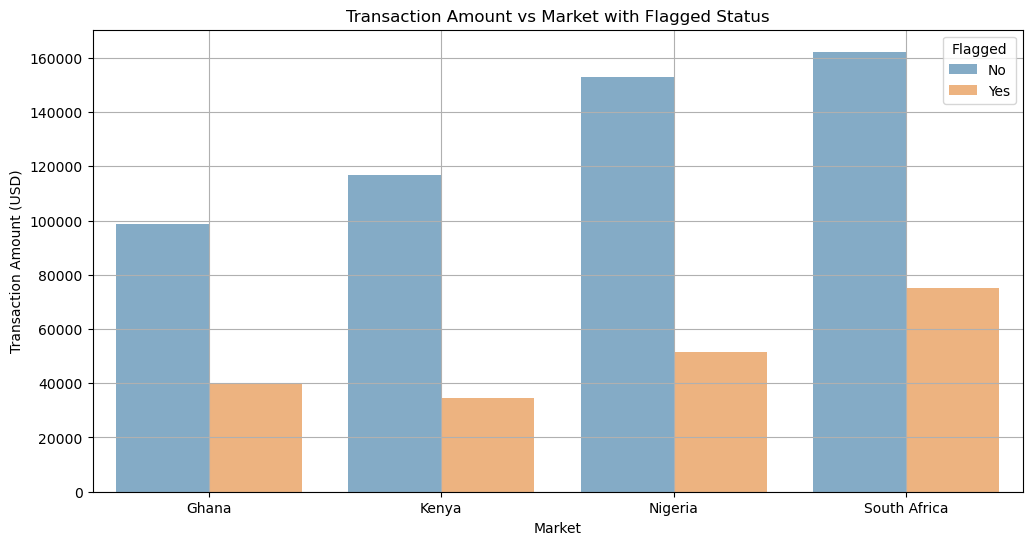

In [76]:
#grouping transation amount by market and flag status and plotting
market_flag_group = df.groupby(["Market", "Fraud_Flag"])["Amount_USD"].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=market_flag_group, x="Market", y="Amount_USD", hue="Fraud_Flag", alpha=0.6)
plt.title("Transaction Amount vs Market with Flagged Status")
plt.xlabel("Market")
plt.ylabel("Transaction Amount (USD)")
plt.legend(title="Flagged")
plt.grid()
plt.show()

In [77]:
#which payment type is marking more revenue and which is declined 
payment_type_revenue = df.groupby(["Payment_Type", "Fraud_Flag"])["Amount_USD"].sum().reset_index()
print(payment_type_revenue)

   Payment_Type Fraud_Flag  Amount_USD
0          Card         No   194470.45
1          Card        Yes    96761.22
2  Mobile Money         No   261659.37
3  Mobile Money        Yes   101574.58
4       QR Code         No    74514.19
5       QR Code        Yes     3057.47


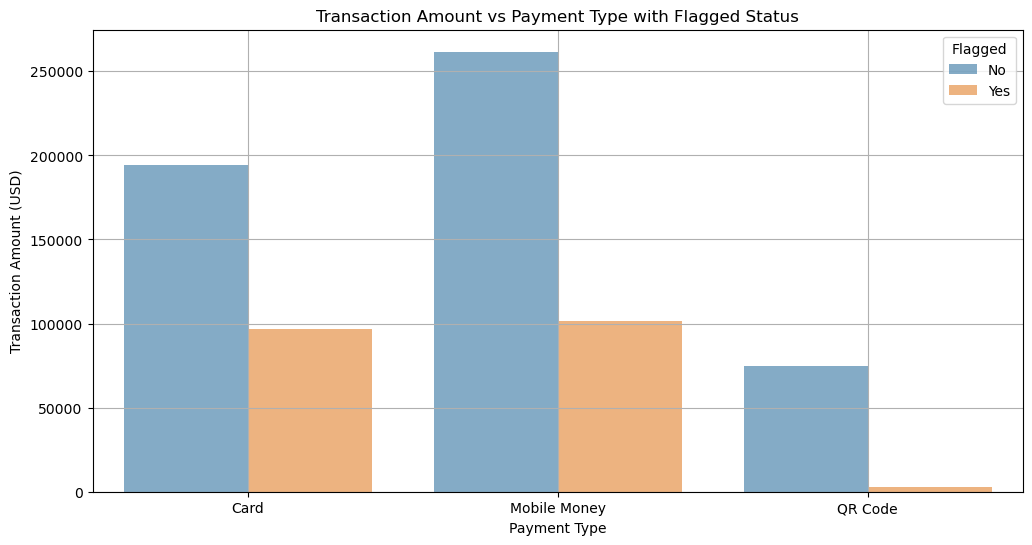

In [78]:
#plotting which payment type is marking more revenue and which is declined
plt.figure(figsize=(12, 6))
sns.barplot(data=payment_type_revenue, x="Payment_Type", y="Amount_USD", hue="Fraud_Flag", alpha=0.6)
plt.title("Transaction Amount vs Payment Type with Flagged Status")
plt.xlabel("Payment Type")
plt.ylabel("Transaction Amount (USD)")
plt.legend(title="Flagged")
plt.grid()
plt.show()

In [79]:
# top 10 merchant making most of revenue in terms of fee_USD
merchant_fee_revenue = df.groupby("Merchant")["Fee_USD"].sum().sort_values(ascending=False)
print(merchant_fee_revenue.head(10))

Merchant
Eskom           395.65
Air Peace       374.74
Woolworths      357.77
Accra Mall      322.97
Checkers        301.74
DStv Kenya      298.72
DSTV SA         293.96
EKEDC           288.51
CMS Hospital    284.91
FlySafair       278.73
Name: Fee_USD, dtype: float64


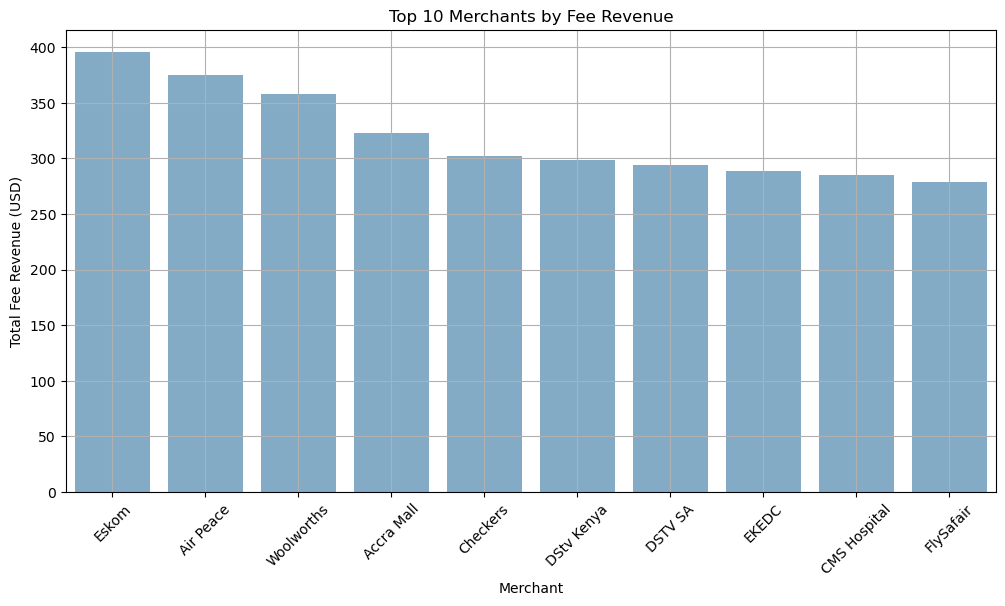

In [80]:
#plotting top 10 merchant making most of revenue in terms of fee_USD
plt.figure(figsize=(12, 6) )
sns.barplot(x=merchant_fee_revenue.head(10).index, y=merchant_fee_revenue.head(10).values, alpha=0.6)
plt.title("Top 10 Merchants by Fee Revenue")
plt.xlabel("Merchant")
plt.ylabel("Total Fee Revenue (USD)")
plt.xticks(rotation=45)
plt.grid()
plt.show()